In [1]:
import rockhound as rh
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import traveltime as tt
from scipy.interpolate import interp1d
print(pg.__version__)

1.5.5


     radius   depth   density       Vpv       Vph      Vsv      Vsh  eta  \
0    6371.0     0.0   1.02000   1.45000   1.45000  0.00000  0.00000  1.0   
1    6370.0     1.0   1.02000   1.45000   1.45000  0.00000  0.00000  1.0   
2    6369.0     2.0   1.02000   1.45000   1.45000  0.00000  0.00000  1.0   
3    6368.0     3.0   1.02000   1.45000   1.45000  0.00000  0.00000  1.0   
4    6368.0     3.0   2.60000   5.80000   5.80000  3.20000  3.20000  1.0   
..      ...     ...       ...       ...       ...      ...      ...  ...   
194   400.0  5971.0  13.05366  11.23711  11.23711  3.65027  3.65027  1.0   
195   300.0  6071.0  13.06890  11.24809  11.24809  3.65794  3.65794  1.0   
196   200.0  6171.0  13.07979  11.25593  11.25593  3.66342  3.66342  1.0   
197   100.0  6271.0  13.08632  11.26063  11.26063  3.66670  3.66670  1.0   
198     0.0  6371.0  13.08850  11.26220  11.26220  3.66780  3.66780  1.0   

      Q_mu  Q_kappa  
0      0.0  57823.0  
1      0.0  57823.0  
2      0.0  57823.0  

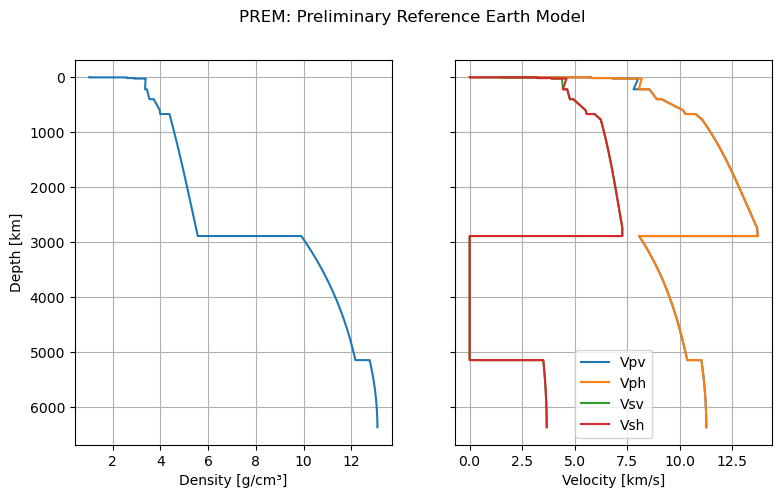

In [2]:
# Load PREM into a DataFrame
prem = rh.fetch_prem()
print(prem)
# Plot density and velocities
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
fig.suptitle("PREM: Preliminary Reference Earth Model")
ax = axes[0]
prem.plot("density", "depth", legend=False, ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Density [g/cm³]")
ax.set_ylabel("Depth [km]")
ax.grid()
ax = axes[1]
for velocity in ["Vpv", "Vph", "Vsv", "Vsh"]:
    prem.plot(velocity, "depth", legend=False, ax=ax, label=velocity)
ax.grid()
ax.legend()
ax.set_xlabel("Velocity [km/s]")
plt.show()

(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>, None)

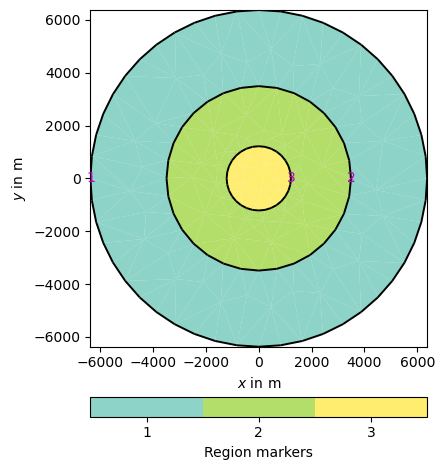

In [3]:
earth = mt.createCircle(radius=6.371e3, nSegments=48, marker=1)
earth.scale([-1, 1])
outercore = mt.createCircle(radius=3.49e3, nSegments=32, marker=2)
innercore = mt.createCircle(radius=1.216e3, nSegments=32, marker=3)
geo = earth+outercore+innercore
pg.show(geo)

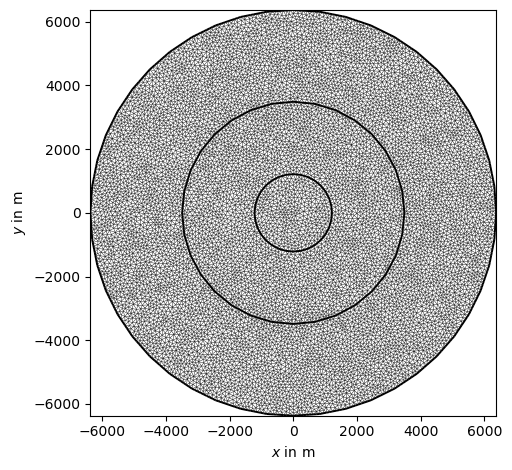

In [4]:
mesh = mt.createMesh(geo, area=1e4)
pg.show(mesh);

11/12/25 - 18:17:10 - pyGIMLi - INFO - Found 3 regions.
11/12/25 - 18:17:10 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
11/12/25 - 18:17:10 - pyGIMLi - INFO - Creating forward mesh from region infos.


Data: Sensors: 48 data: 24, nonzero entries: ['g', 's']


11/12/25 - 18:17:11 - pyGIMLi - INFO - Creating refined mesh (secnodes: 5) to solve forward task.


[  833.36667265  1663.16474127  2485.84088313  3297.8722727
  4095.78166689  4876.1522952   5635.64249077  6371.
  7079.07590914  7756.83812843  8401.38437601  9009.95460588
  9579.9428269  10108.90826199 10594.58579996 11034.89569502
 11427.95247261 11772.07300326 12065.78371003 12307.82687858
 12497.1660429  12632.99042363 12714.71839991 12742.        ]


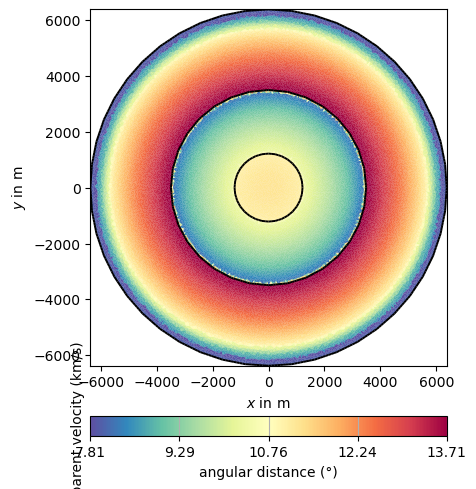

In [5]:
cc = mesh.cellCenters()
rn = np.sqrt(pg.x(cc)**2+pg.y(cc)**2)
ii = np.argsort(rn)
v = np.zeros_like(rn)

# v[ii] = np.interp(rn[ii], rad, prem["Vpv"], "nearest")
f = interp1d(prem["radius"], prem["Vpv"])
v = f(rn)
pg.show(mesh, v, cMap="Spectral_r")


data = tt.DataContainer()
for n in earth.nodes():
    data.createSensor(n.pos())

data.resize(data.sensorCount()//2)
data["s"] = np.zeros(data.size())
data["g"] = np.arange(data.size()) + 1
print(data)
fop = tt.TravelTimeModelling(secNodes=5)
fop.setData(data)
fop.setMesh(mesh)
data["t"] = fop.response(1/v/1000)

dist = tt.shotReceiverDistances(data)

print(dist)
va = dist / data["t"]
ang = data["g"] / data.sensorCount() * 360
plt.plot(ang, va/1000)
plt.xlabel("angular distance (°)")
plt.ylabel("apparent velocity (km/s)")
plt.grid()

11/12/25 - 18:17:22 - pyGIMLi - INFO - Found 3 regions.
11/12/25 - 18:17:22 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
11/12/25 - 18:17:22 - pyGIMLi - INFO - Creating forward mesh from region infos.
11/12/25 - 18:17:22 - pyGIMLi - INFO - Creating refined mesh (secnodes: 5) to solve forward task.


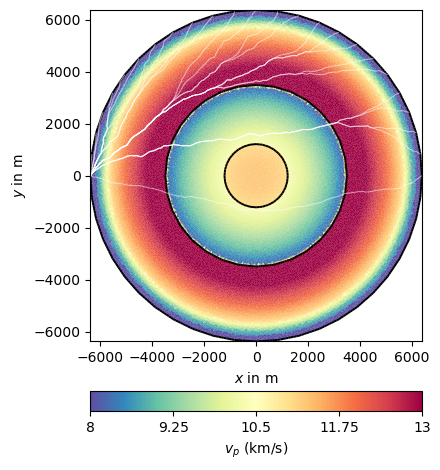

In [6]:
mgr = tt.Manager(data=data, secNodes=5)
mgr.setMesh(mesh)
mgr.inv.setRegularization(background=False)
mgr.fop.createJacobian(1/v/1000)
rp = mgr.getRayPaths(v)
ax, _ = pg.show(mesh, v, cMap="Spectral_r", cMin=8, cMax=13, label=r"$v_p$ (km/s)")
lc = LineCollection(rp, color="white", linewidths=0.8, alpha=0.5)
ax.add_collection(lc);